<a href="https://colab.research.google.com/github/DhimanTarafdar/denv2-mutation-checking-with-vaccine/blob/main/DENV2_MUTATION_CHECKING_WITH_VACCINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Biopython install kori (Colab e pre-installed nao thakte pare)
!pip install biopython -q

# Dorkari library gula import kori
import pandas as pd
from Bio import SeqIO
import matplotlib.pyplot as plt

print("Setup done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.6 MB/s eta 0:00:00
Setup done!


In [2]:
# CSV file load kori
df = pd.read_csv("DENGU-VIRUS-CSV.csv")

# koyta row, koyta column ache dekhi
print("Shape (rows, columns):", df.shape)

# column gulor naam dekhi
print("\nColumns:", df.columns.tolist())

# prothom 5 ta row dekhi
df.head(5)

Shape (rows, columns): (664, 15)

Columns: ['Accession', 'Organism_Name', 'Species', 'Genotype', 'Isolate', 'Length', 'Nuc_Completeness', 'Geo_Location', 'Country', 'Host', 'Tissue_Specimen_Source', 'Submitters', 'Collection_Date', 'Release_Date', 'Molecule_type']


,Accession,Organism_Name,Species,Genotype,Isolate,Length,Nuc_Completeness,Geo_Location,Country,Host,Tissue_Specimen_Source,Submitters,Collection_Date,Release_Date,Molecule_type
0,OZ484492,dengue virus type 2,Orthoflavivirus denguei,NaN,IEDCR-ARBV2500987,10512,complete,Bangladesh:Dhaka,Bangladesh,Homo sapiens,NaN,"Nasif,M.A.O., Alam,A.N., Jony,M.H.K., Bhuiyan,...",2025-10-29,2026-06-17,ssRNA(+)
1,OZ484493,dengue virus type 3,Orthoflavivirus denguei,NaN,IEDCR-ARBV2501060,10461,complete,Bangladesh:Dhaka,Bangladesh,Homo sapiens,NaN,"Nasif,M.A.O., Alam,A.N., Jony,M.H.K., Bhuiyan,...",2025-11-24,2026-06-17,ssRNA(+)
2,OZ484494,dengue virus type 2,Orthoflavivirus denguei,NaN,IEDCR-ARBV2500878,10512,complete,Bangladesh:Dhaka,Bangladesh,Homo sapiens,NaN,"Nasif,M.A.O., Alam,A.N., Jony,M.H.K., Bhuiyan,...",2025-10-08,2026-06-17,ssRNA(+)
3,OZ484495,dengue virus type 2,Orthoflavivirus denguei,NaN,IEDCR-ARBV2500699,10512,complete,Bangladesh:Dhaka,Bangladesh,Homo sapiens,NaN,"Nasif,M.A.O., Alam,A.N., Jony,M.H.K., Bhuiyan,...",2025-08-25,2026-06-17,ssRNA(+)
4,OZ484496,dengue virus type 2,Orthoflavivirus denguei,NaN,IEDCR-ARBV2500892,10512,complete,Bangladesh:Dhaka,Bangladesh,Homo sapiens,NaN,"Nasif,M.A.O., Alam,A.N., Jony,M.H.K., Bhuiyan,...",2025-10-13,2026-06-17,ssRNA(+)


In [3]:
# kon column e koyta missing value ache
print("Missing values per column:")
print(df.isnull().sum())

# proti column er data type
print("\nData types:")
print(df.dtypes)

Missing values per column:
Accession                   0
Organism_Name               0
Species                     0
Genotype                  119
Isolate                    18
Length                      0
Nuc_Completeness            0
Geo_Location                0
Country                     0
Host                       23
Tissue_Specimen_Source    127
Submitters                  9
Collection_Date            14
Release_Date                0
Molecule_type               0
dtype: int64

Data types:
Accession                 object
Organism_Name             object
Species                   object
Genotype                  object
Isolate                   object
Length                     int64
Nuc_Completeness          object
Geo_Location              object
Country                   object
Host                      object
Tissue_Specimen_Source    object
Submitters                object
Collection_Date           object
Release_Date              object
Molecule_type             object
dt

In [4]:
# Species column ba Serotype column theke count kori
print(df['Species'].value_counts())

Species
Orthoflavivirus denguei    664
Name: count, dtype: int64


In [5]:
# Serotype info is actually in Organism_Name column
print(df['Organism_Name'].value_counts())

Organism_Name
dengue virus type 3    223
dengue virus type 2    146
Dengue virus type 2    132
Dengue virus type 3     87
dengue virus type 1     57
dengue virus type I     16
dengue virus type 4      3
Name: count, dtype: int64


count      664.000000
mean      2713.703313
std       3518.539699
min        150.000000
25%       1056.000000
50%       1479.000000
75%       1485.000000
max      10723.000000
Name: Length, dtype: float64


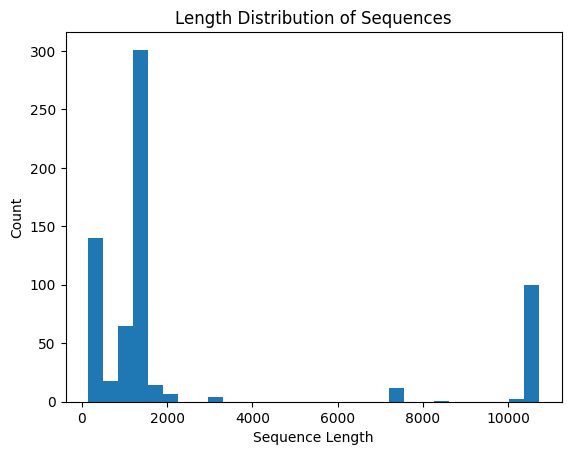

In [6]:
# Basic statistics of sequence length
print(df['Length'].describe())

# Length distribution plot
plt.hist(df['Length'], bins=30)
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Length Distribution of Sequences")
plt.show()

In [7]:
# Convert Collection_Date to datetime
df['Collection_Date'] = pd.to_datetime(df['Collection_Date'], errors='coerce')

# Extract year
df['Year'] = df['Collection_Date'].dt.year

# Count sequences per year
print(df['Year'].value_counts().sort_index())

Year
2006.0    11
2007.0     3
2008.0     6
2009.0     1
2017.0     2
2018.0    31
2019.0    29
2020.0     1
2021.0    22
2022.0    39
2023.0    36
2024.0    20
2025.0    38
Name: count, dtype: int64


In [8]:
# Which location inside Bangladesh has most samples
print(df['Geo_Location'].value_counts())

Geo_Location
Bangladesh                565
Bangladesh: Dhaka          28
Bangladesh:Dhaka           24
Bangladesh: Barishal       18
Bangladesh: Cumilla        18
Bangladesh: Chattogram      8
Bangladesh:Cox's Bazar      2
Bangladesh:Barguna          1
Name: count, dtype: int64


In [9]:
# See how serotypes are distributed across years
cross_table = pd.crosstab(df['Year'], df['Organism_Name'])
cross_table

Organism_Name,Dengue virus type 2,Dengue virus type 3,dengue virus type 1,dengue virus type 2,dengue virus type 3,dengue virus type 4,dengue virus type I
Year,,,,,,,
2006.0,2,9,0,0,0,0,0
2007.0,1,2,0,0,0,0,0
2008.0,3,3,0,0,0,0,0
2009.0,1,0,0,0,0,0,0
2017.0,0,0,0,0,2,0,0
2018.0,13,11,0,6,1,0,0
2019.0,2,23,0,0,4,0,0
2020.0,0,0,0,0,0,0,1
2021.0,0,0,22,0,0,0,0


In [10]:
# Load FASTA file and count total sequences
sequences = list(SeqIO.parse("DENGUE-VIRUS-sequences.fasta", "fasta"))

print("Total sequences in FASTA:", len(sequences))

# Check first sequence id and length
print("First sequence ID:", sequences[0].id)
print("First sequence length:", len(sequences[0].seq))

Total sequences in FASTA: 664
First sequence ID: OZ484492.1
First sequence length: 10512


In [11]:
# Compare FASTA count with CSV row count
print("CSV rows:", len(df))
print("FASTA sequences:", len(sequences))

# Check if counts match
if len(df) == len(sequences):
    print("Match! Same number of records in both files.")
else:
    print("Mismatch! Need to investigate.")

CSV rows: 664
FASTA sequences: 664
Match! Same number of records in both files.


In [12]:
# Fix 1: Standardize serotype names
def clean_serotype(name):
    name = name.lower()
    if "type 1" in name or "type i" in name:
        return "DENV-1"
    elif "type 2" in name:
        return "DENV-2"
    elif "type 3" in name:
        return "DENV-3"
    elif "type 4" in name:
        return "DENV-4"
    else:
        return "Unknown"

df['Serotype'] = df['Organism_Name'].apply(clean_serotype)

# Check corrected counts
print(df['Serotype'].value_counts())

Serotype
DENV-3    310
DENV-2    278
DENV-1     73
DENV-4      3
Name: count, dtype: int64


In [13]:
# Fix 2: Check raw Collection_Date values before parsing to see the problem
raw_dates = pd.read_csv("DENGU-VIRUS-CSV.csv")['Collection_Date']

# Show some examples that failed to parse
failed = raw_dates[df['Collection_Date'].isna()]
print("Examples of unparseable dates:")
print(failed.unique()[:20])

Examples of unparseable dates:
['2023-06' '2023-11' '2023-07' '2023-09' '2018' '2019' '2021' '2022'
 '2021-08' '2021-10' '2017-10' '2017-11' '2017-12' '2017' '2017-09'
 '2017-08' '2011' '2009-10' '2009' '2008']


In [14]:
# Fix 3: Check Nuc_Completeness to separate full genome vs partial gene
print(df['Nuc_Completeness'].value_counts())

# Check length range by serotype (helps confirm E-gene vs full genome split)
print(df.groupby('Serotype')['Length'].describe())

Nuc_Completeness
partial     596
complete     68
Name: count, dtype: int64
          count         mean          std     min     25%      50%      75%  \
Serotype                                                                      
DENV-1     73.0  4987.246575  4590.457187   395.0  1479.0   1485.0  10610.0   
DENV-2    278.0  2129.169065  2991.746316   150.0   510.0   1485.0   1485.0   
DENV-3    310.0  2655.854839  3420.517117   232.0  1479.0   1479.0   1479.0   
DENV-4      3.0  7535.333333  5154.005853  1584.0  6047.5  10511.0  10511.0   

              max  
Serotype           
DENV-1    10673.0  
DENV-2    10723.0  
DENV-3    10707.0  
DENV-4    10511.0  


In [15]:
# Fix 4: Clean Geo_Location spacing issue
df['Geo_Location_Clean'] = df['Geo_Location'].str.replace(":", ": ").str.replace("  ", " ").str.strip()
print(df['Geo_Location_Clean'].value_counts())

Geo_Location_Clean
Bangladesh                 565
Bangladesh: Dhaka           52
Bangladesh: Barishal        18
Bangladesh: Cumilla         18
Bangladesh: Chattogram       8
Bangladesh: Cox's Bazar      2
Bangladesh: Barguna          1
Name: count, dtype: int64


In [16]:
# Fix year extraction using regex - works for any date format
df['Year'] = df['Collection_Date'].astype(str).str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Now check year distribution properly
print(df['Year'].value_counts().sort_index())
print("\nTotal non-missing years:", df['Year'].notna().sum())

Year
2006.0    11
2007.0     3
2008.0     6
2009.0     1
2017.0     2
2018.0    31
2019.0    29
2020.0     1
2021.0    22
2022.0    39
2023.0    36
2024.0    20
2025.0    38
Name: count, dtype: int64

Total non-missing years: 239


In [17]:
# Cross check: Serotype vs Nuc_Completeness
print(pd.crosstab(df['Serotype'], df['Nuc_Completeness']))

Nuc_Completeness  complete  partial
Serotype                           
DENV-1                   7       66
DENV-2                  22      256
DENV-3                  37      273
DENV-4                   2        1


In [18]:
# Focus dataset: separate complete genomes (for reference-quality check)
complete_df = df[df['Nuc_Completeness'] == 'complete']
print("Complete genomes per serotype:")
print(complete_df['Serotype'].value_counts())

Complete genomes per serotype:
Serotype
DENV-3    37
DENV-2    22
DENV-1     7
DENV-4     2
Name: count, dtype: int64


In [19]:
# Focus dataset: partial sequences that are close to E-gene length (1400-1600 bp)
partial_egene = df[(df['Nuc_Completeness'] == 'partial') & (df['Length'].between(1400, 1600))]

print("Likely E-gene-only sequences per serotype:")
print(partial_egene['Serotype'].value_counts())

Likely E-gene-only sequences per serotype:
Serotype
DENV-3    175
DENV-2     95
DENV-1     32
DENV-4      1
Name: count, dtype: int64


In [20]:
# Reload the raw CSV fresh so original date strings are intact
raw_df = pd.read_csv("DENGU-VIRUS-CSV.csv")

# Extract year from the ORIGINAL raw string column, not the corrupted one
df['Year'] = raw_df['Collection_Date'].astype(str).str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Check result again
print(df['Year'].value_counts().sort_index())
print("\nTotal non-missing years:", df['Year'].notna().sum())

Year
2001.0      1
2002.0      4
2004.0      1
2005.0      1
2006.0     12
2007.0      4
2008.0      7
2009.0      6
2011.0      1
2017.0    136
2018.0     90
2019.0     70
2020.0      1
2021.0    101
2022.0     78
2023.0     79
2024.0     20
2025.0     38
Name: count, dtype: int64

Total non-missing years: 650


# **VACCINE DATA EXPLORE**

In [22]:
# Load the DENV-2 vaccine reference file
vaccine_denv2 = list(SeqIO.parse("/content/TAK-003 DENV2.fasta", "fasta"))

# Basic info about this reference
print("Number of sequences in file:", len(vaccine_denv2))
print("Sequence ID:", vaccine_denv2[0].id)
print("Sequence description:", vaccine_denv2[0].description)
print("Sequence length:", len(vaccine_denv2[0].seq))

Number of sequences in file: 1
Sequence ID: KU725664.1
Sequence description: KU725664.1 Dengue virus type 2 strain PDK53, complete genome
Sequence length: 10723


In [23]:
# Check for ambiguous bases (like N) in the reference
seq_str = str(vaccine_denv2[0].seq)
n_count = seq_str.count("N")
print("Number of 'N' (unknown) bases in reference:", n_count)

Number of 'N' (unknown) bases in reference: 0


In [24]:
# Filter DENV-2 rows from the main CSV
denv2_df = df[df['Serotype'] == 'DENV-2']

print("Total DENV-4 sequences:", len(denv2_df))
print("\nBreakdown by completeness:")
print(denv2_df['Nuc_Completeness'].value_counts())

Total DENV-4 sequences: 278

Breakdown by completeness:
Nuc_Completeness
partial     256
complete     22
Name: count, dtype: int64


In [25]:
# Show length and basic metadata for DENV-2 sequences (complete genomes only)
denv2_complete = denv2_df[denv2_df['Nuc_Completeness'] == 'complete']

denv2_complete[['Accession', 'Length', 'Isolate', 'Collection_Date', 'Geo_Location']]

,Accession,Length,Isolate,Collection_Date,Geo_Location
0,OZ484492,10512,IEDCR-ARBV2500987,2025-10-29,Bangladesh:Dhaka
2,OZ484494,10512,IEDCR-ARBV2500878,2025-10-08,Bangladesh:Dhaka
3,OZ484495,10512,IEDCR-ARBV2500699,2025-08-25,Bangladesh:Dhaka
4,OZ484496,10512,IEDCR-ARBV2500892,2025-10-13,Bangladesh:Dhaka
5,OZ484497,10512,IEDCR-ARBV2500037,2025-01-16,Bangladesh:Dhaka
6,OZ484498,10512,IEDCR-CBD625009,2025-06-17,Bangladesh:Barguna
7,OZ484499,10512,IEDCR-ARBV2501007,2025-11-02,Bangladesh:Dhaka
13,OZ484505,10512,IEDCR-ARBV2501041,2025-11-13,Bangladesh:Dhaka
15,OZ484507,10512,IEDCR-ARBV2500916,2025-10-16,Bangladesh:Dhaka
16,OZ484508,10512,IEDCR-ARBV2501044,2025-11-16,Bangladesh:Dhaka


In [27]:
# Get list of accession numbers for DENV-2 complete genomes
denv2_accessions = denv2_complete['Accession'].tolist()

# Extract matching sequences from the big FASTA file
denv2_seq_records = [seq for seq in sequences if seq.id.split(".")[0] in denv2_accessions]

print("Matched sequences found:", len(denv2_seq_records))

# Show their IDs and lengths
for record in denv2_seq_records:
    print(record.id, "-", len(record.seq), "bp")

Matched sequences found: 22
OZ484492.1 - 10512 bp
OZ484494.1 - 10512 bp
OZ484495.1 - 10512 bp
OZ484496.1 - 10512 bp
OZ484497.1 - 10512 bp
OZ484498.1 - 10512 bp
OZ484499.1 - 10512 bp
OZ484505.1 - 10512 bp
OZ484507.1 - 10512 bp
OZ484508.1 - 10512 bp
OZ484509.1 - 10512 bp
OZ484512.1 - 10512 bp
OZ484514.1 - 10512 bp
OZ484518.1 - 10512 bp
PQ657766.1 - 10723 bp
LC436669.1 - 10671 bp
LC436670.1 - 10671 bp
LC436671.1 - 10671 bp
LC436672.1 - 10671 bp
LC436673.1 - 10671 bp
LC436674.1 - 10671 bp
LC436675.1 - 10671 bp


In [28]:
# Pick one Bangladesh DENV-2 sample to compare against vaccine reference
sample_seq = denv2_seq_records[0]
vaccine_seq = vaccine_denv2[0]

print("Vaccine ref:", vaccine_seq.id, len(vaccine_seq.seq), "bp")
print("Sample:", sample_seq.id, len(sample_seq.seq), "bp")

Vaccine ref: KU725664.1 10723 bp
Sample: OZ484492.1 10512 bp


In [29]:
# Global alignment using Needleman-Wunsch
from Bio import Align

aligner = Align.PairwiseAligner()
aligner.mode = 'global'
aligner.match_score = 1
aligner.mismatch_score = -1
aligner.open_gap_score = -2
aligner.extend_gap_score = -0.5

global_alignments = aligner.align(str(vaccine_seq.seq), str(sample_seq.seq))
best_global = global_alignments[0]

print("Global alignment score:", best_global.score)

Global alignment score: 8293.5


In [30]:
# Count mutations from the global alignment
a1, a2 = str(best_global[0]), str(best_global[1])

substitutions = sum(1 for x, y in zip(a1, a2) if x != y and x != '-' and y != '-')
indels = sum(1 for x, y in zip(a1, a2) if x == '-' or y == '-')
identity = sum(1 for x, y in zip(a1, a2) if x == y) / len(a1) * 100

print("Substitutions:", substitutions)
print("Indel positions:", indels)
print("Identity: %.2f%%" % identity)

Substitutions: 1055
Indel positions: 211
Identity: 88.19%


In [31]:
# Local alignment using Smith-Waterman, for comparison
aligner.mode = 'local'
local_alignments = aligner.align(str(vaccine_seq.seq), str(sample_seq.seq))
best_local = local_alignments[0]

a1_l, a2_l = str(best_local[0]), str(best_local[1])
substitutions_l = sum(1 for x, y in zip(a1_l, a2_l) if x != y and x != '-' and y != '-')
indels_l = sum(1 for x, y in zip(a1_l, a2_l) if x == '-' or y == '-')
identity_l = sum(1 for x, y in zip(a1_l, a2_l) if x == y) / len(a1_l) * 100

print("Aligned region length:", len(a1_l))
print("Substitutions:", substitutions_l)
print("Indel positions:", indels_l)
print("Identity: %.2f%%" % identity_l)

Aligned region length: 10512
Substitutions: 1055
Indel positions: 0
Identity: 89.96%


In [32]:
# Align each complete DENV-2 genome against the vaccine reference
import pandas as pd

vaccine_str = str(vaccine_seq.seq)
results = []

for record in denv2_seq_records:
    aln = aligner.align(vaccine_str, str(record.seq))[0]
    a1, a2 = str(aln[0]), str(aln[1])

    subs = sum(1 for x, y in zip(a1, a2) if x != y and x != '-' and y != '-')
    indels = sum(1 for x, y in zip(a1, a2) if x == '-' or y == '-')
    identity = sum(1 for x, y in zip(a1, a2) if x == y) / len(a1) * 100

    results.append({
        "Accession": record.id,
        "Length": len(record.seq),
        "Substitutions": subs,
        "Indels": indels,
        "Identity_%": round(identity, 2)
    })

mutation_table = pd.DataFrame(results)
mutation_table

,Accession,Length,Substitutions,Indels,Identity_%
0,OZ484492.1,10512,1055,0,89.96
1,OZ484494.1,10512,2297,0,78.15
2,OZ484495.1,10512,1439,0,86.31
3,OZ484496.1,10512,1223,0,88.37
4,OZ484497.1,10512,1909,54,81.37
5,OZ484498.1,10512,1782,0,83.05
6,OZ484499.1,10512,1621,0,84.58
7,OZ484505.1,10512,1013,0,90.36
8,OZ484507.1,10512,1230,0,88.30
9,OZ484508.1,10512,1232,0,88.28


In [33]:
# Summary statistics across all 22 genomes
print(mutation_table[["Substitutions", "Indels", "Identity_%"]].describe())

       Substitutions     Indels  Identity_%
count      22.000000  22.000000   22.000000
mean     1158.772727   3.090909   88.986818
std       480.547994  11.409725    4.632598
min        56.000000   0.000000   78.150000
25%       806.500000   0.000000   86.577500
50%      1152.500000   0.000000   89.040000
75%      1411.000000   2.000000   92.425000
max      2297.000000  54.000000   99.480000


In [34]:
# Sort to see the most and least divergent strains
mutation_table.sort_values("Identity_%")

,Accession,Length,Substitutions,Indels,Identity_%
1,OZ484494.1,10512,2297,0,78.15
4,OZ484497.1,10512,1909,54,81.37
5,OZ484498.1,10512,1782,0,83.05
6,OZ484499.1,10512,1621,0,84.58
2,OZ484495.1,10512,1439,0,86.31
11,OZ484512.1,10512,1438,0,86.32
12,OZ484514.1,10512,1330,0,87.35
9,OZ484508.1,10512,1232,0,88.28
8,OZ484507.1,10512,1230,0,88.30
13,OZ484518.1,10512,1224,0,88.36


# **CYD-TDV DENV2**

In [37]:
# Load the DENV-2 vaccine reference file
vaccine_denv2_cyd = list(SeqIO.parse("/content/CYD-TVD DENV2.fasta", "fasta"))

# Basic info about this reference
print("Number of sequences in file:", len(vaccine_denv2_cyd))
print("Sequence ID:", vaccine_denv2_cyd[0].id)
print("Sequence description:", vaccine_denv2_cyd[0].description)
print("Sequence length:", len(vaccine_denv2_cyd[0].seq))

Number of sequences in file: 1
Sequence ID: KX239895.1
Sequence description: KX239895.1 Synthetic construct isolate CYD2 surface protein gene, partial cds
Sequence length: 1983


In [38]:
# Pick one Bangladesh DENV-2 sample to compare against vaccine reference
sample_seq = denv2_seq_records[0]
vaccine_seq = vaccine_denv2_cyd[0]

print("Vaccine ref:", vaccine_seq.id, len(vaccine_seq.seq), "bp")
print("Sample:", sample_seq.id, len(sample_seq.seq), "bp")

Vaccine ref: KX239895.1 1983 bp
Sample: OZ484492.1 10512 bp


In [39]:
# Local alignment using Smith-Waterman, for comparison
aligner.mode = 'local'
local_alignments = aligner.align(str(vaccine_seq.seq), str(sample_seq.seq))
best_local = local_alignments[0]

a1_l, a2_l = str(best_local[0]), str(best_local[1])
substitutions_l = sum(1 for x, y in zip(a1_l, a2_l) if x != y and x != '-' and y != '-')
indels_l = sum(1 for x, y in zip(a1_l, a2_l) if x == '-' or y == '-')
identity_l = sum(1 for x, y in zip(a1_l, a2_l) if x == y) / len(a1_l) * 100

print("Aligned region length:", len(a1_l))
print("Substitutions:", substitutions_l)
print("Indel positions:", indels_l)
print("Identity: %.2f%%" % identity_l)

Aligned region length: 1983
Substitutions: 147
Indel positions: 4
Identity: 92.39%


# **TV 003 DENV2**

In [41]:
# Load the DENV-2 vaccine reference file
vaccine_denv2_TV = list(SeqIO.parse("/content/TV 003 DENV2.fasta", "fasta"))

# Basic info about this reference
print("Number of sequences in file:", len(vaccine_denv2_TV))
print("Sequence ID:", vaccine_denv2_TV[0].id)
print("Sequence description:", vaccine_denv2_TV[0].description)
print("Sequence length:", len(vaccine_denv2_TV[0].seq))

Number of sequences in file: 1
Sequence ID: KM204118.1
Sequence description: KM204118.1 Dengue virus 2 strain New Guinea C, complete genome
Sequence length: 10723


In [42]:
# Pick one Bangladesh DENV-2 sample to compare against vaccine reference
sample_seq = denv2_seq_records[0]
vaccine_seq = vaccine_denv2_TV[0]

print("Vaccine ref:", vaccine_seq.id, len(vaccine_seq.seq), "bp")
print("Sample:", sample_seq.id, len(sample_seq.seq), "bp")

Vaccine ref: KM204118.1 10723 bp
Sample: OZ484492.1 10512 bp


In [43]:
# Global alignment using Needleman-Wunsch
from Bio import Align

aligner = Align.PairwiseAligner()
aligner.mode = 'global'
aligner.match_score = 1
aligner.mismatch_score = -1
aligner.open_gap_score = -2
aligner.extend_gap_score = -0.5

global_alignments = aligner.align(str(vaccine_seq.seq), str(sample_seq.seq))
best_global = global_alignments[0]

print("Global alignment score:", best_global.score)

Global alignment score: 8423.5


In [44]:
# Count mutations from the global alignment
a1, a2 = str(best_global[0]), str(best_global[1])

substitutions = sum(1 for x, y in zip(a1, a2) if x != y and x != '-' and y != '-')
indels = sum(1 for x, y in zip(a1, a2) if x == '-' or y == '-')
identity = sum(1 for x, y in zip(a1, a2) if x == y) / len(a1) * 100

print("Substitutions:", substitutions)
print("Indel positions:", indels)
print("Identity: %.2f%%" % identity)

Substitutions: 990
Indel positions: 211
Identity: 88.80%
